═══════════════════════════════════════════════════════
# 🎨 Project 3 — Multimodal Image Generation Studio
# ════════════════════════════════════════════════
#  Internship  : Decode Labs — Multimodal Image Generation Studio
#  Developer   : Taj Wali Khan
#  Platform    : Google Colab

# 🎨 Project 3 — Multimodal Image Generation Studio
### DecodeLabs Generative AI Internship | Built by Taj Wali Khan

This notebook builds a text-to-image generation studio using **Stable Diffusion v1.5** (free, open-weight) running on Colab's **free T4 GPU** — no paid API key required.

**Before running anything:** go to `Runtime` -> `Change runtime type` -> select **T4 GPU** -> Save.


## Step 1 — Confirm the free GPU is active


In [1]:
!nvidia-smi


Sat Jul 11 19:52:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Install only what's missing (pinned, stable versions)


In [2]:
# Colab already ships a CUDA-matched torch build.
# We do NOT reinstall torch -- that's the #1 cause of "CUDA not available" errors.
!pip install --quiet diffusers==0.39.0 transformers accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 75.1 MB/s eta 0:00:00


## Step 3 — Load the model


In [3]:
import torch
from diffusers import StableDiffusionPipeline

assert torch.cuda.is_available(), "No GPU detected -- check Runtime > Change runtime type."

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"  # free, open-weight model

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # half precision fits comfortably on the free T4
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()  # small speed trade-off for a lot of memory safety


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## Step 4 — Parameter payload: aspect ratio -> exact pixel dimensions
SD1.5 downsamples by a factor of 8 internally, so width/height must always be multiples of 8, or generation fails.


In [4]:
ASPECT_RATIOS = {
    "Square (1:1)":    {"width": 512, "height": 512},
    "Portrait (2:3)":  {"width": 512, "height": 768},
    "Landscape (3:2)": {"width": 768, "height": 512},
}


## Step 5 — Safety gates, integrity check, and the core generation function
This function carries the production-engineering lessons from the training deck, adapted from a remote-API context to a local-GPU context:
- **Gate 1 (pre-generation):** basic keyword blocklist on the input prompt.
- **Gate 2 (post-generation):** the model's built-in NSFW safety checker.
- **Integrity verification:** re-open and fully decode every saved file before trusting it.
- **Graceful failure:** catch GPU out-of-memory errors instead of crashing the notebook.


In [5]:
import gc
from pathlib import Path
from PIL import Image

OUTPUT_DIR = Path("/content/generated_images")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Gate 1: Pre-generation input filtering ---
# A real product uses a trained moderation classifier. As a first safeguard, we
# block a short list of clearly unsafe categories before spending any GPU time.
BLOCKED_KEYWORDS = ["explicit", "gore", "self-harm"]


def validate_prompt(prompt: str) -> str:
    """
    Clean and validate a user prompt before it reaches the model.

    Args:
        prompt: Raw text typed by the user.

    Returns:
        The cleaned prompt string.

    Raises:
        ValueError: If the prompt is empty, too long, or blocked.
    """
    cleaned = prompt.strip()
    if not cleaned:
        raise ValueError("Prompt cannot be empty.")
    if len(cleaned) > 500:
        raise ValueError("Prompt is too long (max 500 characters).")
    if any(term in cleaned.lower() for term in BLOCKED_KEYWORDS):
        raise ValueError("This prompt was blocked by the content safety gate.")
    return cleaned


def generate_image(
    prompt: str,
    aspect_ratio: str = "Square (1:1)",
    num_images: int = 1,
    steps: int = 30,
    guidance_scale: float = 7.5,
    seed: int = None,
):
    """
    Generate one or more images from a text prompt using Stable Diffusion.

    Args:
        prompt: Natural-language description of the desired image.
        aspect_ratio: One of the keys in ASPECT_RATIOS.
        num_images: How many images to generate at once.
        steps: Denoising steps (higher = better quality, slower).
        guidance_scale: How strictly to follow the prompt (7-8 is a good default).
        seed: Optional int for reproducible output.

    Returns:
        List of (PIL.Image, file_path) tuples for images that passed both
        the safety checker and the file-integrity check.
    """
    clean_prompt = validate_prompt(prompt)
    dims = ASPECT_RATIOS[aspect_ratio]

    generator = torch.Generator("cuda")
    if seed is not None:
        generator = generator.manual_seed(seed)

    try:
        result = pipe(
            prompt=clean_prompt,
            width=dims["width"],
            height=dims["height"],
            num_images_per_prompt=num_images,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            generator=generator,
        )
    except torch.cuda.OutOfMemoryError:
        # Local equivalent of "FAIL FAST, do not wait" for a dead network --
        # here it's a full GPU instead of a dead server.
        torch.cuda.empty_cache()
        gc.collect()
        raise RuntimeError("GPU ran out of memory. Try a smaller aspect ratio or fewer images.")

    saved = []
    for i, (image, is_unsafe) in enumerate(zip(result.images, result.nsfw_content_detected)):
        # --- Gate 2: Post-generation output filtering ---
        if is_unsafe:
            print(f"Image {i} was flagged by the safety checker and discarded.")
            continue

        file_path = OUTPUT_DIR / f"{abs(hash(clean_prompt))}_{i}.png"
        image.save(file_path)

        # --- Integrity verification: forced pixel-level decode ---
        try:
            with Image.open(file_path) as check:
                check.load()
        except OSError:
            print(f"Image {i} failed integrity verification and was discarded.")
            file_path.unlink(missing_ok=True)
            continue

        saved.append((image, file_path))

    return saved


## Step 6 — A simple visual interface (the "studio")


In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

prompt_box = widgets.Text(
    placeholder="e.g. a Peshawari chappal on a wooden table, studio lighting",
    description="Prompt:",
    layout=widgets.Layout(width="600px"),
)
ratio_dropdown = widgets.Dropdown(options=list(ASPECT_RATIOS.keys()), description="Aspect ratio:")
generate_button = widgets.Button(description="Generate", button_style="success")
output_area = widgets.Output()

def on_generate_click(_):
    with output_area:
        clear_output()
        print("Generating... (roughly 15-30 seconds on a free T4)")
        try:
            for image, path in generate_image(prompt_box.value, ratio_dropdown.value):
                display(image)
                print(f"Saved to: {path}")
        except (ValueError, RuntimeError) as exc:
            print(f"Warning: {exc}")

generate_button.on_click(on_generate_click)
display(prompt_box, ratio_dropdown, generate_button, output_area)


Text(value='', description='Prompt:', layout=Layout(width='600px'), placeholder='e.g. a Peshawari chappal on a…

Dropdown(description='Aspect ratio:', options=('Square (1:1)', 'Portrait (2:3)', 'Landscape (3:2)'), value='Sq…

Button(button_style='success', description='Generate', style=ButtonStyle())

Output()

## Step 7 — Quick test run (no widget needed)


  0%|          | 0/30 [00:00<?, ?it/s]

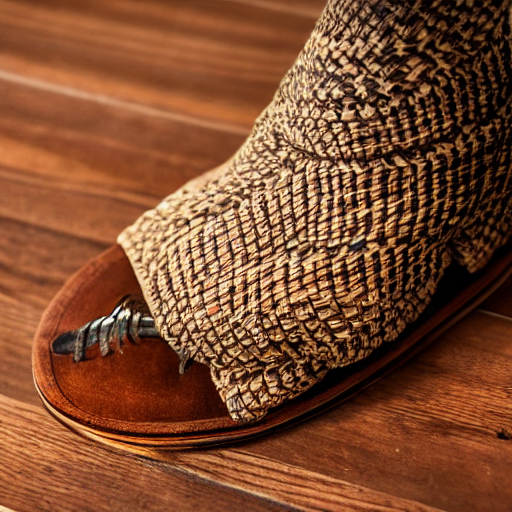

In [7]:
results = generate_image(
    "a hand-woven Peshawari chappal on a wooden table, studio lighting",
    aspect_ratio="Square (1:1)",
    seed=42,
)
for image, path in results:
    display(image)


## Recap: what you just built
- **Text-to-image API integration** -> a self-hosted, free, open-weight model.
- **Parameter payloads** -> the `ASPECT_RATIOS` mapping and generation kwargs.
- **Dual security gates** -> `validate_prompt()` (pre) + `nsfw_content_detected` (post).
- **Integrity verification** -> forced `Image.open().load()` re-decode before trusting a file.
- **Graceful failure handling** -> catching `torch.cuda.OutOfMemoryError` instead of crashing.

### Suggested next milestones
1. Add **style presets** (cyberpunk, minimalism, watercolor) as prompt-suffix templates.
2. Add a **batch mode**: generate 4 variations and let the user pick a favorite.
3. Zip and download all generated images at the end of a session.
4. (Advanced) Swap in an automated quality check using CLIP similarity scoring, as described in the training deck's "Automated QA" section.

**Note on responsible use:** this model ships under the CreativeML OpenRAIL-M license. Keep the built-in safety checker enabled, don't use it to generate content depicting real people without consent, and treat the keyword blocklist above as a starting point, not a complete safety solution.
